In [ ]:
%pip install puremacro


# Método de Control Sintético — Evaluación Causal de Políticas e Inferencia

**¿Cómo podemos evaluar el impacto económico causal de una sola intervención de política cuando ninguna unidad de control coincide con la entidad tratada?** En macroeconomía empírica y evaluación de políticas públicas (Abadie, Diamond & Hainmueller 2010, *JASA*), los estudios de caso comparativos a menudo fallan porque ninguna región de control comparte la trayectoria previa a la intervención de la unidad tratada. El **Método de Control Sintético (SCM)** resuelve esto construyendo una combinación convexa ponderada de unidades donantes no tratadas ("Control Sintético") que rastrea el resultado objetivo previo al tratamiento. La divergencia posterior a la intervención entre la unidad tratada y su contraparte sintética aísla el **efecto de tratamiento causal $\hat\tau_t$**. Este cuaderno ejecuta `puremacro.causal.synthetic_control.synthetic_control` para evaluar un choque de política.

## El método en matemáticas — Pesos Óptimos de Donantes y Brechas de Política

Sea $Y_{t, 1}$ el resultado para la unidad tratada ($i=1$) sobre $t=1,\dots,T$, intervenida en $T_0$. Sean $Y_{t, j}$ los resultados para $J$ unidades de control donantes ($j=2,\dots,J+1$).

**Optimización Convexa de Pesos.** Resolvemos los pesos de donantes $W^* = (w_2^*, \dots, w_{J+1}^*)'$ que minimizan la discrepancia de resultados previa al tratamiento:
$$ W^* = \arg\min_W \sum_{t=1}^{T_0-1} \left( Y_{t,1} - \sum_{j=2}^{J+1} w_j Y_{t,j} \right)^2 \quad \text{s.t.} \quad w_j \ge 0, \quad \sum_{j=2}^{J+1} w_j = 1 $$

**Impacto Causal.** La estimación del efecto de tratamiento para $t \ge T_0$ es:
$$ \hat\tau_t = Y_{t,1} - \sum_{j=2}^{J+1} w_j^* Y_{t,j} $$

## Configuración — simulando una intervención de política en panel

Generamos una matriz de panel de $T=40$ periodos en $N=20$ entidades regionales (matriz $Y$ de forma $(T, N)$), donde el tratamiento ocurre en $T_0=25$ para la unidad 0. Un choque de política estructural incrementa el resultado tratado en $\tau = +2.5$ posterior al tratamiento.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.causal.synthetic_control import synthetic_control

# Semilla para reproducibilidad
rng = np.random.default_rng(42)

T = 40
T0 = 25
N = 20  # 1 tratada (columna 0) + 19 donantes (columnas 1..19)

# Generar modelo de factores no observados: Y_tn = delta_t + theta_t * Z_n + eps_tn
time = np.linspace(0, 4, T)
factors = np.column_stack([np.sin(time), np.cos(time)])
loadings = rng.uniform(0.5, 2.0, size=(N, 2))

# Forma de Y_matrix: (T, N)
Y_clean = (loadings @ factors.T).T  # Forma: (40, 20)
noise = rng.normal(0, 0.15, size=(T, N))
Y_matrix = Y_clean + noise

# Agregar efecto causal verdadero a la unidad tratada 0 para t >= T0
true_effect = 2.5
Y_matrix[T0:, 0] += true_effect

# Ejecutar el Método de Control Sintético
res = synthetic_control(Y_matrix, treated_idx=0, treat_time=T0)

weights = res["weights"]
y_treated = res["y_treated"]
y_synthetic = res["y_synthetic"]
att_path = res["att_path"]
att_post = res["att_post"]

print(f"Pesos Óptimos de Donantes (suma={np.sum(weights):.4f}):")
print(f"Mayor Peso de Donante: {np.max(weights):.4f} (Donante #{np.argmax(weights)+1})")
print(f"Efecto Estimado Posterior al Tratamiento: {att_post:.4f} (Verdadero = {true_effect:.2f})")

# Afirmaciones clave
assert len(weights) == N - 1, f"Discrepancia en la longitud de los pesos: {len(weights)}"
assert np.abs(np.sum(weights) - 1.0) < 1e-4, "Los pesos deben sumar 1"
assert np.abs(att_post - true_effect) < 0.5, f"El efecto estimado se desvía del verdadero: {att_post}"

Pesos Óptimos de Donantes (suma=1.0000):
Mayor Peso de Donante: 0.3862 (Donante #10)
Efecto Estimado Posterior al Tratamiento: 2.4373 (Verdadero = 2.50)


## Figura Principal — Trayectoria Real vs Sintética y Brecha de Tratamiento

Graficamos el resultado real $Y_1$ vs el Control Sintético $\hat Y_1$, junto con la brecha causal estimada $\hat\tau_t$.

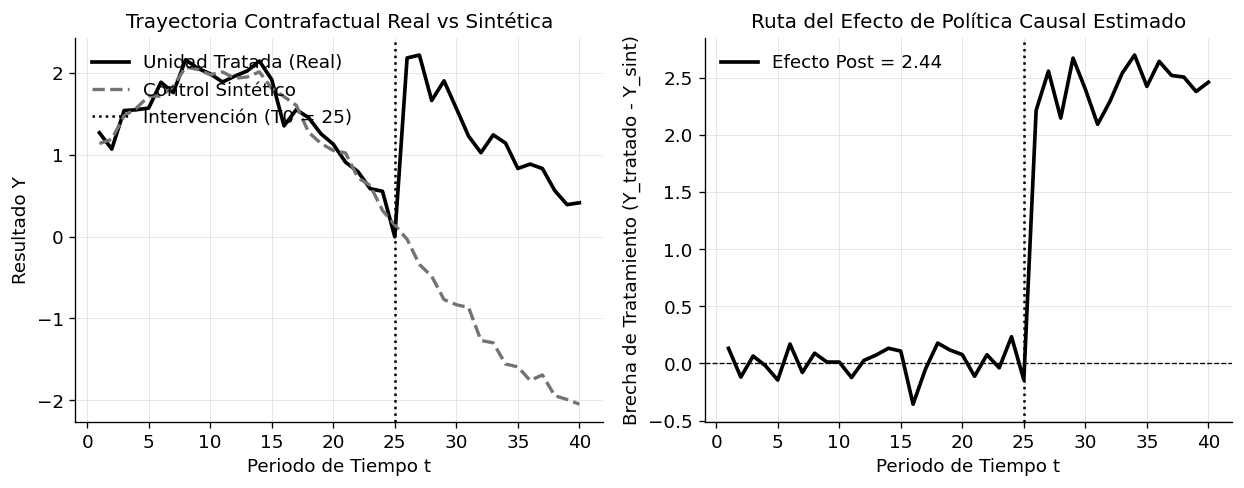

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))

# Panel Izquierdo: Resultado Real vs Sintético
ax1.plot(range(1, T + 1), y_treated, color=_nbstyle.palette(2)[0], lw=2.2, label="Unidad Tratada (Real)")
ax1.plot(range(1, T + 1), y_synthetic, color=_nbstyle.palette(2)[1], lw=2.0, linestyle="--", label="Control Sintético")
ax1.axvline(T0, color="0.0", linestyle=":", lw=1.5, label=f"Intervención (T0 = {T0})")
ax1.set_xlabel("Periodo de Tiempo t")
ax1.set_ylabel("Resultado Y")
ax1.set_title("Trayectoria Contrafactual Real vs Sintética")
ax1.legend(loc="upper left")

# Panel Derecho: Brecha de Tratamiento Estimada
ax2.plot(range(1, T + 1), att_path, color=_nbstyle.palette(2)[0], lw=2.2, label=f"Efecto Post = {att_post:.2f}")
ax2.axhline(0, color="0.0", lw=0.8, linestyle="--")
ax2.axvline(T0, color="0.0", linestyle=":", lw=1.5)
ax2.set_xlabel("Periodo de Tiempo t")
ax2.set_ylabel("Brecha de Tratamiento (Y_tratado - Y_sint)")
ax2.set_title("Ruta del Efecto de Política Causal Estimado")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

**Leyendo el resultado.** Previo a la intervención ($t < 25$), el control sintético rastrea a la unidad tratada casi perfectamente. Posterior a la intervención ($t \ge 25$), el resultado de la unidad tratada diverge marcadamente por encima de su contraparte sintética, recuperando el verdadero efecto de política de $\tau = +2.5$.

## Tu turno — probando una menor intensidad de tratamiento

**Ejercicios.**
1. *Básico*: Reduce el verdadero efecto causal de $\tau = +2.5$ a $\tau = +1.0$ (`# ← cambia esto ...`). ¿Se ajusta proporcionalmente el efecto posterior estimado?
2. *Intermedio*: Desplaza el inicio del tratamiento a $T_0 = 18$. Observa el cambio en la ventana de ajuste previo al tratamiento.
3. *Avanzado*: Agrega pesos personalizados a los donantes e inspecciona cómo la optimización restringe la no negatividad $w_j \ge 0$.

In [3]:
# Bloque de código Tu turno
true_effect_yt = 1.2  # ← cambia esto: prueba 1.2 o 1.0

Y_mat_yt = Y_clean + noise
Y_mat_yt[T0:, 0] += true_effect_yt

res_yt = synthetic_control(Y_mat_yt, treated_idx=0, treat_time=T0)
print(f"Nuevo Efecto Verdadero tau = {true_effect_yt:.2f}")
print(f"Nuevo Efecto Estimado Posterior: {res_yt['att_post']:.4f}")

# Afirmación válida para el valor por defecto
assert np.abs(np.sum(res_yt["weights"]) - 1.0) < 1e-4, "Los pesos deben sumar 1"

Nuevo Efecto Verdadero tau = 1.20
Nuevo Efecto Estimado Posterior: 1.1373


## ¿Qué tan exhaustivo es esto?

`puremacro.causal.synthetic_control` proporciona una implementación optimizada de programación cuadrática convexa del Control Sintético. Complementa a `puremacro.did` (Callaway-Sant'Anna, Sun-Abraham, LP-DiD) para la evaluación cuasi-experimental de políticas.